In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoModelForCausalLM,GPT2Tokenizer
import requests

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# Explicitly set the loss type
gpt2.config.loss_type = "ForCausalLMLoss"

In [39]:
# Set Hyperparameters
seq_len = 256
batch_size = 16

In [40]:
# tokenize the text
# Gulliver's travels :)
text = requests.get('https://www.gutenberg.org/cache/epub/829/pg829.txt').text

gtTokens = gpt2_tokenizer.encode(text, return_tensors='pt')
print(gtTokens.shape)

gtTokens = gtTokens[0]
print(f'{gtTokens.shape}')

Token indices sequence length is longer than the specified maximum sequence length for this model (158345 > 1024). Running this sequence through the model will result in indexing errors


torch.Size([1, 158345])
torch.Size([158345])


In [41]:
# find the top 100 most frequently occurring tokens
uniq, counts = gtTokens.unique(return_counts=True)
idx = counts.argsort(descending=True)[:100]
top100 = uniq[idx]

for t in top100:
  print(f'Token {t:5} appears {torch.sum(gtTokens==t):4} times and is "{gpt2_tokenizer.decode(t)}"')

Token    11 appears 10060 times and is ","
Token   198 appears 9919 times and is "
"
"
Token   262 appears 5393 times and is " the"
Token   286 appears 3779 times and is " of"
Token   290 appears 3467 times and is " and"
Token   284 appears 3356 times and is " to"
Token    13 appears 3004 times and is "."
Token   314 appears 2657 times and is " I"
Token   257 appears 2431 times and is " a"
Token   287 appears 1900 times and is " in"
Token    26 appears 1562 times and is ";"
Token   616 appears 1474 times and is " my"
Token   373 appears 1199 times and is " was"
Token   326 appears 1061 times and is " that"
Token   502 appears  964 times and is " me"
Token   351 appears  941 times and is " with"
Token   355 appears  920 times and is " as"
Token   465 appears  823 times and is " his"
Token   416 appears  794 times and is " by"
Token   329 appears  776 times and is " for"
Token   543 appears  774 times and is " which"
Token   447 appears  734 times and is "�"
Token   340 appears  718 time

In [42]:
from collections import Counter
most_common_tokens = Counter(gtTokens.tolist()).most_common(100)

for t, c in most_common_tokens:
  print(f'Token {t:5} appears {c:4} times and is "{gpt2_tokenizer.decode(t)}"')


Token    11 appears 10060 times and is ","
"
Token   198 appears 9919 times and is "
"
Token   262 appears 5393 times and is " the"
Token   286 appears 3779 times and is " of"
Token   290 appears 3467 times and is " and"
Token   284 appears 3356 times and is " to"
Token    13 appears 3004 times and is "."
Token   314 appears 2657 times and is " I"
Token   257 appears 2431 times and is " a"
Token   287 appears 1900 times and is " in"
Token    26 appears 1562 times and is ";"
Token   616 appears 1474 times and is " my"
Token   373 appears 1199 times and is " was"
Token   326 appears 1061 times and is " that"
Token   502 appears  964 times and is " me"
Token   351 appears  941 times and is " with"
Token   355 appears  920 times and is " as"
Token   465 appears  823 times and is " his"
Token   416 appears  794 times and is " by"
Token   329 appears  776 times and is " for"
Token   543 appears  774 times and is " which"
Token   447 appears  734 times and is "�"
Token   340 appears  718 time

In [43]:
# move the model to the GPU
gpt2 = gpt2.to(device)

In [44]:
# check out some text
prompt = 'I cannot believe that'
in2gpt = gpt2_tokenizer.encode(prompt,return_tensors='pt').to(device)

# Create an attention mask for the input (all ones since it's a single, non-padded sequence)
attention_mask = torch.ones(in2gpt.shape, device=device, dtype=torch.long)

output = gpt2.generate(in2gpt, attention_mask=attention_mask, max_length=100, pad_token_id=gpt2_tokenizer.eos_token_id, do_sample=True).cpu()
print(gpt2_tokenizer.decode(output[0]))

I cannot believe that we're going out of space. It would be so unfair if we never got to the moon, but one of those 'dereliction of duty' things is that we don't have time for that. I'm not saying it never could have happened at all, but you'd better start worrying about it now, because we just weren't able to get a really good shot of those two."<|endoftext|>


# Quantify the frequency of GT frequent tokens in GPT's output

In [45]:
numreps =  10 # number of random repetitions
numtoks = 100 # output length

# random starting tokens
randstarts = torch.randint(gpt2_tokenizer.vocab_size,(numreps,1)).to(device)

# generate some data
out = gpt2.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [gpt2_tokenizer.encode(gpt2_tokenizer.eos_token)],
  pad_token_id = gpt2_tokenizer.encode(gpt2_tokenizer.eos_token)[0]
).cpu()

print(out,'\n')

for o in out:
  print('\n*** Next batch of output:')
  print(gpt2_tokenizer.decode(o))

tensor([[ 4766,   389,  1171,  ...,  3119,   287,   281],
        [39946,   378,   357,  ...,  1872,    86,  5282],
        [15221,   290,   547,  ...,   597,  2683,   357],
        ...,
        [18618,   422,   477,  ...,   561,   635, 10400],
        [ 3694,    11,   351,  ...,   407, 14765,   284],
        [33279,   198,   198,  ...,   198,     2,  2488]]) 


*** Next batch of output:
yright are public domain and must be approved by all members of the Site's original 'Printer Friendly' community. If you are visiting or using our website, your rights are solely responsible for ensuring that you are not violating your posting privacy policy. Copyright Notice (or related legal notices, including Copyright Notice Agreement, Terms of Use Notice and Privacy Policy) and Privacy Policy will be posted here and we have no obligation to update this privacy policy. If you wish to use any of our services or property in an

*** Next batch of output:
 Hospate (Rescue Dogs Unit) is working to addre

In [46]:
# calculate and report the percentage
percentFreqTokens_pre = np.mean(100*np.isin(out[:,1:],top100).flatten())
print(f"Gulliver's travels common tokens appeared in {percentFreqTokens_pre}% of new tokens.")

Gulliver's travels common tokens appeared in 39.2% of new tokens.


# Fine-tune the model

In [47]:
# create the optimizer functions (note the small learning rate)
optimizer = torch.optim.AdamW(gpt2.parameters(), lr=5e-5, weight_decay=.01)

In [48]:
num_epochs = 1000

# initialize losses
train_loss = np.zeros(num_epochs)

for epochi in range(num_epochs):

  # get a batch of data
  ix = torch.randint(len(gtTokens)-seq_len,size=(batch_size,))
  X  = gtTokens[ix[:,None] + torch.arange(seq_len)]

  # move data to GPU
  X = X.to(device)

  # clear previous gradients
  gpt2.zero_grad()

  # forward pass (Hugging Face shifts X internally to get y)
  outputs = gpt2(X,labels=X)
  loss = outputs.loss

  # backprop
  loss.backward()
  optimizer.step()

  # store the per-sample loss
  train_loss[epochi] = loss.item()

  # update progress display
  if epochi%100==0:
    print(f'Sample {epochi:4}/{num_epochs}, train loss: {train_loss[epochi]:.4f}')

Sample    0/1000, train loss: 5.4527
Sample  100/1000, train loss: 2.9319
Sample  200/1000, train loss: 2.5853
Sample  300/1000, train loss: 2.2290
Sample  400/1000, train loss: 1.7930
Sample  500/1000, train loss: 1.2519
Sample  600/1000, train loss: 0.9313
Sample  700/1000, train loss: 0.7649
Sample  800/1000, train loss: 0.3904
Sample  900/1000, train loss: 0.2917


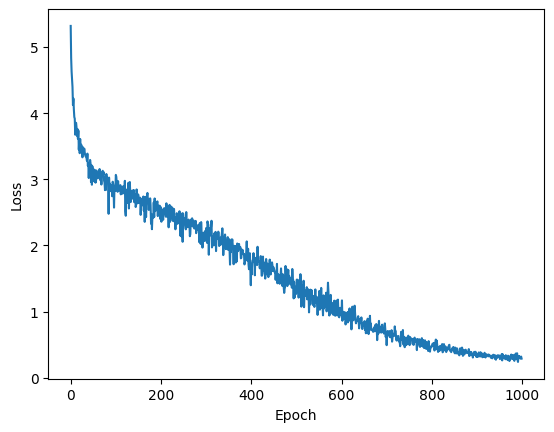

In [32]:
plt.plot(train_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [33]:
# check out some text
prompt = 'I cannot believe that'
in2gpt = gpt2_tokenizer.encode(prompt,return_tensors='pt').to(device)

# Create an attention mask for the input (all ones since it's a single, non-padded sequence)
attention_mask = torch.ones(in2gpt.shape, device=device, dtype=torch.long)

output = gpt2.generate(in2gpt, attention_mask=attention_mask, max_length=100, pad_token_id=gpt2_tokenizer.eos_token_id, do_sample=True).cpu()
print(gpt2_tokenizer.decode(output[0]))

I cannot believe that I never said what I spoke; and
that the astonishment on my face grew equal, as I thought, to putting it
together. But he was pleased to entertain a guess as high as to have
allowed my whole being was body: so that I was certainly a rational creature
even of my own contradictions: and yet, for want of sufficient reason, I
appeared to be little at least prepared for such a reality.



In [36]:
# random starting tokens
randstarts = torch.randint(gpt2_tokenizer.vocab_size,(numreps,1)).to(device)

# generate some data
out = gpt2.generate(
  randstarts,
  max_length = numtoks+1,
  min_length = numtoks+1,
  do_sample  = True,
  bad_words_ids = [gpt2_tokenizer.encode(gpt2_tokenizer.eos_token)],
  pad_token_id = gpt2_tokenizer.encode(gpt2_tokenizer.eos_token)[0]
).cpu()


for o in out:
  print('\n*** Next batch of output:')
  print(gpt2_tokenizer.decode(o))


*** Next batch of output:
Jews want
to know, by the end of next month’s, that your imperial majesty,
if he be found, in good behaviour, would offer his courtesy to reward you
for your service.”

I gave orders, by the master of the carriage to carry me to the
island of Tonquineseus, a title fixed on the most ancient and easy
method of acquiring riches. I related to him the history I had

*** Next batch of output:
 Pacage and the Folly; and
afterwards on the Downs and Hopscotch, when I had occasion; for they were
all spent with eating, drinking, and passing the night
being far from the senses, they just roused from sleep, for they
heard the bellowing directly in the Old Fashioned’s mouth, and immediately
populated the neighbouring squares, opening the most doors for me and
the reader, who were immediately

*** Next batch of output:
 as I happened to put in an hour of my labour, and by their help would
remain in that intention ever since.” By this I meant, that I was resolved to
live but

In [37]:
# calculate and report the percentage
percentFreqTokens_pst = np.mean(100*np.isin(out[:,1:],top100).flatten())

print(f'Common GT tokens usage went from {percentFreqTokens_pre:.2f}% to {percentFreqTokens_pst:.2f}% after fine-tuning.')

Common GT tokens usage went from 39.70% to 59.50% after fine-tuning.


In [49]:
nn.NLLLoss??